<a href="https://colab.research.google.com/github/MonaKhadija/colab-git-assignment2-kb/blob/main/Lesson_5_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment - EDA using Pandas**

***Instructions***
- Clone a copy of the assignment notebook in Google Colab.
- **Complete the tasks by filling in the code where indicated by TODO comments. Put each task in a new cell.**
- Run each cell to ensure your code works correctly.
- Pay attention to the output of each cell and interpret the results.
- For visualisation tasks, make sure to label axes, add titles, and choose appropriate colour schemes.
- After completing all tasks, review your findings and include notes of your insights gained from the EDA process as markdown notes for assessments.


In [1]:
# Titanic Dataset Exploratory Data Analysis

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Task 1: Load the Titanic dataset
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
df = pd.read_csv(url)
df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [3]:
#Task 2: Inspect the data

print("--- Head ---")
display(df.head())

print("--- Tail ---")
display(df.tail())

print("--- Data Types ---")
print(df.dtypes)

print("--- Summary Statistics ---")
display(df.describe())

--- Head ---


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


--- Tail ---


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.00
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.00
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.45
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.00
886,0,3,Mr. Patrick Dooley,male,32.0,0,0,7.75


--- Data Types ---
Survived                     int64
Pclass                       int64
Name                        object
Sex                         object
Age                        float64
Siblings/Spouses Aboard      int64
Parents/Children Aboard      int64
Fare                       float64
dtype: object
--- Summary Statistics ---


,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


In [4]:
# Task 3: Clean and preprocess the data

# Convert Pclass to a categorical string representation
df['PclassCategory'] = df['Pclass'].map({1: '1st', 2: '2nd', 3: '3rd'}).astype('category')

# Create CabinCategory
if 'Cabin' in df.columns:
    df['CabinCategory'] = df['Cabin'].str[0].fillna('Unknown').astype('category')
else:
    df['CabinCategory'] = 'Unknown'

# Fill missing Age values with the mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Combine Siblings/Spouses and Parents/Children into Family size
sib_col = 'Siblings/Spouses Aboard' if 'Siblings/Spouses Aboard' in df.columns else 'SibSp'
par_col = 'Parents/Children Aboard' if 'Parents/Children Aboard' in df.columns else 'Parch'

df['Family'] = df[sib_col] + df[par_col] + 1
df[['Age', 'PclassCategory', 'CabinCategory', 'Family']].head()

,Age,PclassCategory,CabinCategory,Family
0,22.0,3rd,Unknown,2
1,38.0,1st,Unknown,2
2,26.0,3rd,Unknown,1
3,35.0,1st,Unknown,2
4,35.0,3rd,Unknown,1


In [5]:
# Task 4: Identify specific data points
highest_fare_passengers = df[df['Fare'] == df['Fare'].max()]
largest_family_passengers = df[df['Family'] == df['Family'].max()]

print("Highest Fare Passenger(s):")
display(highest_fare_passengers)

print("Largest Family Size Passenger(s):")
display(largest_family_passengers)

Highest Fare Passenger(s):


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,PclassCategory,CabinCategory,Family
257,1,1,Miss. Anna Ward,female,35.0,0,0,512.3292,1st,Unknown,1
676,1,1,Mr. Thomas Drake Martinez Cardeza,male,36.0,0,1,512.3292,1st,Unknown,2
733,1,1,Mr. Gustave J Lesurer,male,35.0,0,0,512.3292,1st,Unknown,1


Largest Family Size Passenger(s):


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,PclassCategory,CabinCategory,Family
158,0,3,Master. Thomas Henry Sage,male,5.0,8,2,69.55,3rd,Unknown,11
179,0,3,Miss. Constance Gladys Sage,female,8.0,8,2,69.55,3rd,Unknown,11
200,0,3,Mr. Frederick Sage,male,17.0,8,2,69.55,3rd,Unknown,11
322,0,3,Mr. George John Jr Sage,male,20.0,8,2,69.55,3rd,Unknown,11
788,0,3,Miss. Stella Anna Sage,female,21.0,8,2,69.55,3rd,Unknown,11
842,0,3,Mr. Douglas Bullen Sage,male,18.0,8,2,69.55,3rd,Unknown,11
859,0,3,Miss. Dorothy Edith Sage,female,14.0,8,2,69.55,3rd,Unknown,11


In [6]:
# Task 5: Demonstrate Pandas Series and DataFrame functionalities
# Series of passenger names
names_series = df['Name']

# DataFrame of names and ages
names_ages_df = df[['Name', 'Age']]

# Slicing for passengers older than 50
older_passengers = df[df['Age'] > 50]
older_passengers.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,PclassCategory,CabinCategory,Family
6,0,1,Mr. Timothy J McCarthy,male,54.0,0,0,51.8625,1st,Unknown,1
11,1,1,Miss. Elizabeth Bonnell,female,58.0,0,0,26.5500,1st,Unknown,1
15,1,2,Mrs. (Mary D Kingcome) Hewlett,female,55.0,0,0,16.0000,2nd,Unknown,1
33,0,2,Mr. Edward H Wheadon,male,66.0,0,0,10.5000,2nd,Unknown,1
53,0,1,Mr. Engelhart Cornelius Ostby,male,65.0,0,1,61.9792,1st,Unknown,2


In [7]:
# Task 6: Introduce multi-indexing
multi_index_df = df.groupby(['Sex', 'Pclass'])[['Survived']].mean()
display(multi_index_df)

Survived
Sex    Pclass          
female 1       0.968085
       2       0.921053
       3       0.500000
male   1       0.368852
       2       0.157407
       3       0.137026

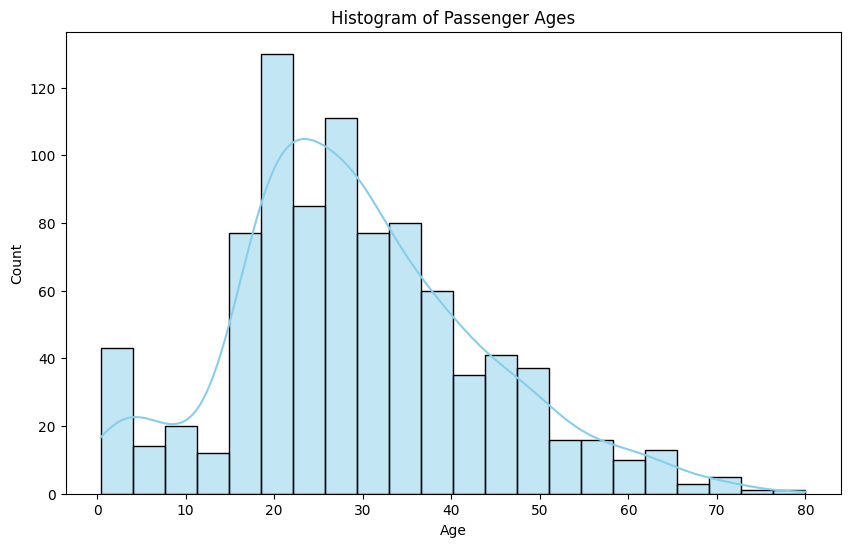

/tmp/ipykernel_1645/3860816158.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='viridis')


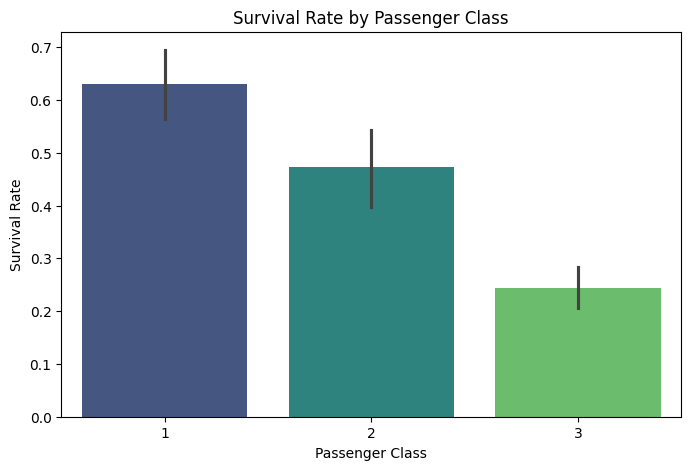

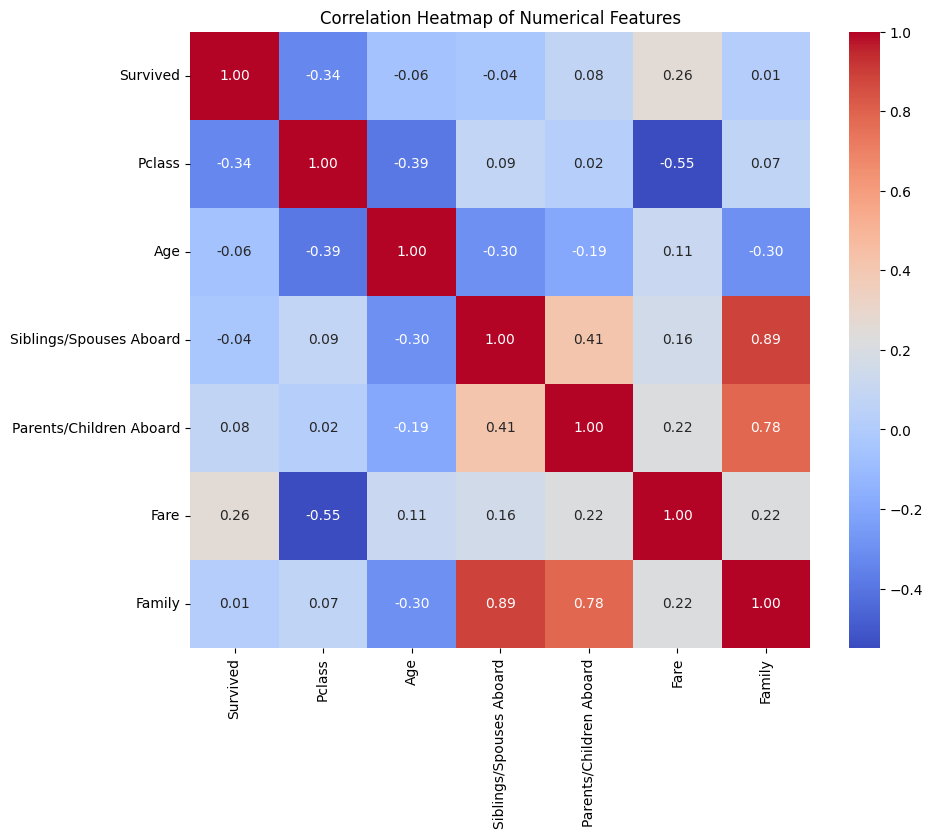

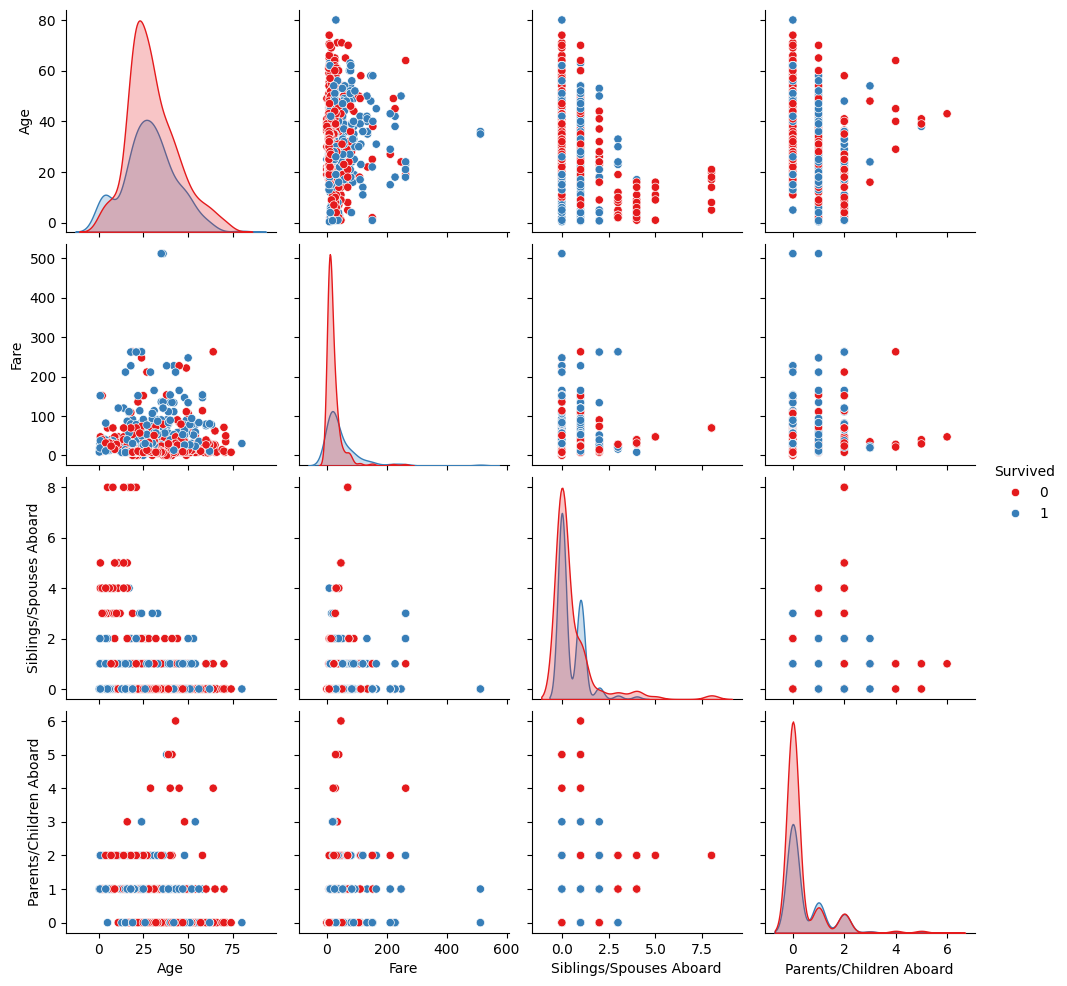

In [8]:
# Task 7: Visualizations
# Histogram of passenger ages
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Bar plot of survival rates by passenger class
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Pclass', y='Survived', palette='viridis')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

# Heatmap of correlation between numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Pair plot of selected features colored by Survived
pairplot_cols = ['Age', 'Fare', sib_col, par_col, 'Survived']
sns.pairplot(df[pairplot_cols], hue='Survived', palette='Set1')
plt.show()

In [9]:
# Task 8: Analyze survival rates
survival_by_sex = df.groupby('Sex')['Survived'].mean()
survival_by_class = df.groupby('Pclass')['Survived'].mean()

print("Survival Rate by Sex:\n", survival_by_sex)
print("\nSurvival Rate by Class:\n", survival_by_class)

Survival Rate by Sex:
 Sex
female    0.742038
male      0.190227
Name: Survived, dtype: float64

Survival Rate by Class:
 Pclass
1    0.629630
2    0.472826
3    0.244353
Name: Survived, dtype: float64


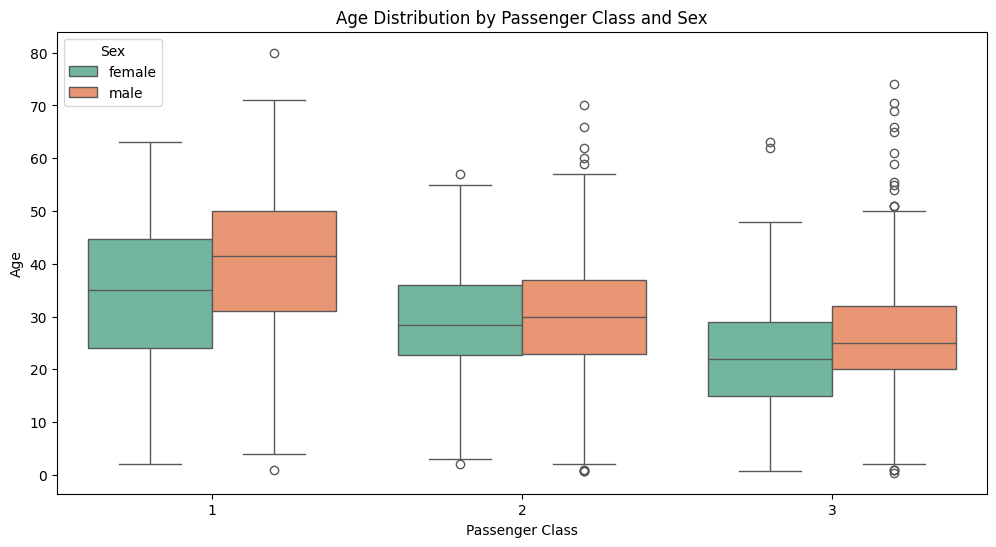

In [10]:
# Task 9: Analyze age distribution
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Pclass', y='Age', hue='Sex', palette='Set2')
plt.title('Age Distribution by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()

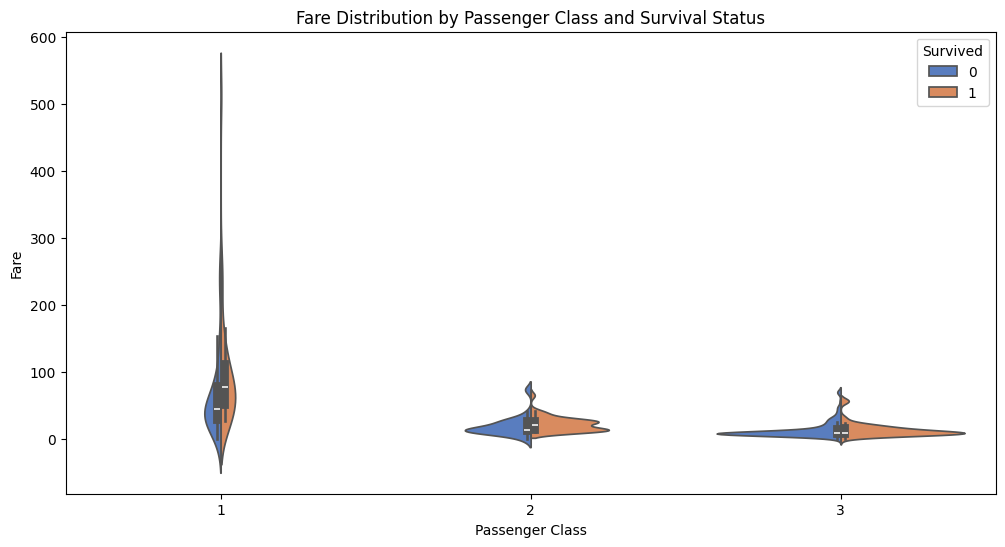

In [11]:
# Task 10: Analyze fare distribution
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Pclass', y='Fare', hue='Survived', split=True, palette='muted')
plt.title('Fare Distribution by Passenger Class and Survival Status')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

In [12]:


print("EDA tasks completed.")

EDA tasks completed.


**Insights: **

Female passengers had a significantly higher survival rate compared to male passengers, with Passengers in 1st Class had the highest survival rates.
we can notice that 1st Class passengers tended to be older on average, whereas 3rd Class had a younger demographic.
Higher fares strongly correlate with higher survival rates, largely tied to 1st-class .

GITHUB link:
